In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# 查看训练集数据，确定缺失值的处理方法

### 读取训练集，一共80个特征

In [83]:
train_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv", index_col = 0)
print((train_df.columns))

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

精心挑选其中的评估类特征(其实是猜的)，后面仅以这17个特征作为预测的特征。

In [84]:
key_features = ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                'BsmtFinType2', 'HeatingQC', 'KitchenQual',  'Functional', 
                'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'CentralAir']

### 确定重要特征, 作图

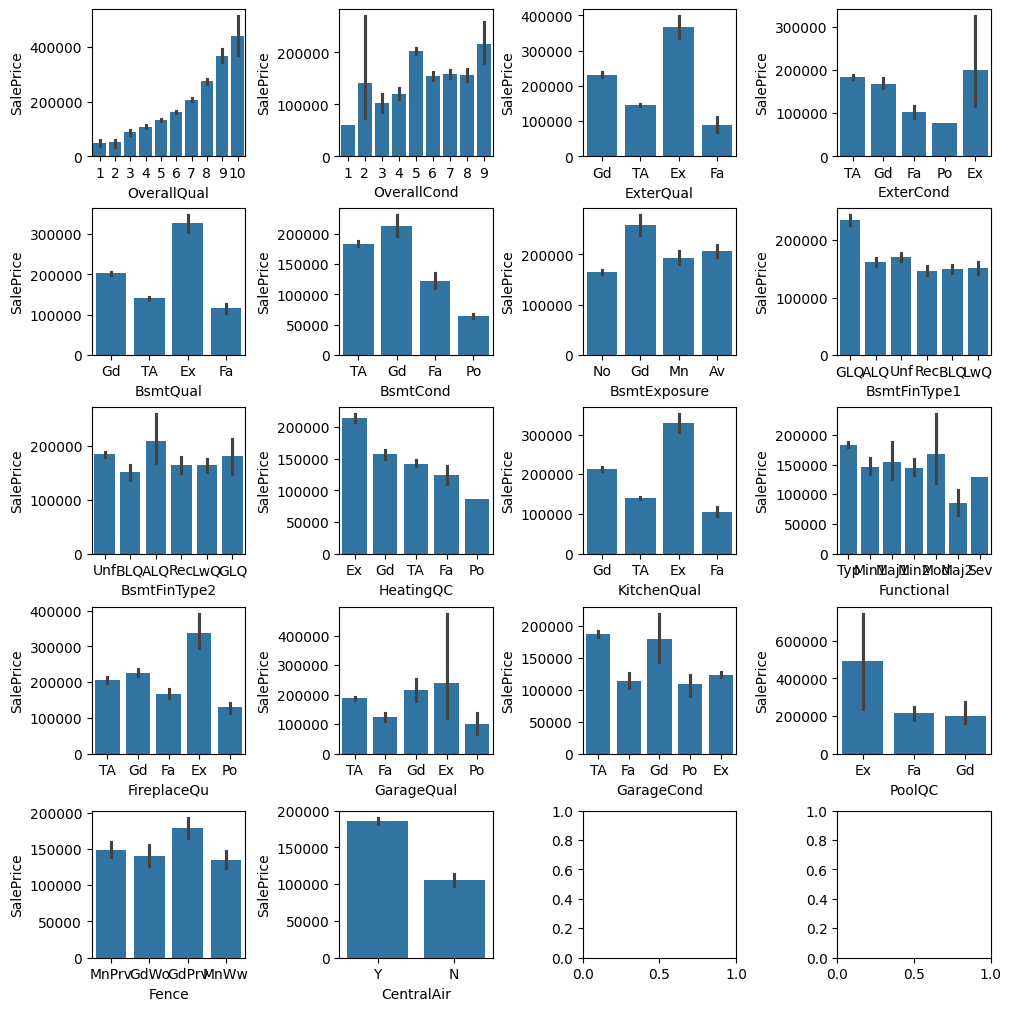

In [85]:
fig, ax =plt.subplots(5,4,constrained_layout=True, figsize=(10, 10))
ax = ax.flatten()
for i in range(18):
    sns.barplot(x = train_df[key_features[i]], y = train_df['SalePrice'], ax = ax[i])

In [86]:
# 定义一个列表，每个元素为 (列名, 映射字典)
mappings = [
    ('ExterQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('ExterCond', {'Ex': 5, 'Gd': 3, 'TA': 4, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('BsmtQual', {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'NA': 0}),
    ('BsmtCond', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('BsmtExposure', {'Gd': 5, 'Av': 4, 'Mn': 3, 'No': 2, 'NA': 1}),
    ('BsmtFinType1', {'GLQ': 6, 'ALQ': 4, 'BLQ': 2, 'Rec': 1, 'LwQ': 3, 'Unf': 5, 'NA': 0}),
    ('BsmtFinType2', {'GLQ': 4, 'ALQ': 6, 'BLQ': 1, 'Rec': 3, 'LwQ': 2, 'Unf': 5, 'NA': 0}),
    ('HeatingQC', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('KitchenQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('Functional', {'Typ': 8, 'Min1': 5, 'Min2': 4, 'Mod': 7, 'Maj1': 6, 'Maj2': 2, 'Sev': 3, 'Sal': 1, 'NA': 0}),
    ('FireplaceQu', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('GarageQual', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('GarageCond', {'Ex': 3, 'Gd': 4, 'TA': 5, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('PoolQC', {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}),
    ('Fence', {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0}), 
    ('CentralAir', {'Y': 2, 'N': 1, 'NA': 0})
]

for col, mapping in mappings:
    train_df[col] = train_df[col].map(mapping)

In [87]:
# fig, ax =plt.subplots(5,4,constrained_layout=True, figsize=(10, 10))
# ax = ax.flatten()
# for i in range(18):
#     sns.barplot(x = train_df[key_features[i]], y = train_df['SalePrice'], ax = ax[i])

### 处理缺失值

先合并train和test

In [88]:
test_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv", index_col = 0)
all_df = pd.concat((train_df, test_df),axis = 0)
key_features.append('SalePrice')
all_df = all_df[key_features]        #删除不需要的特征
all_df.shape

(2919, 19)

In [89]:
for col, mapping in mappings:
    all_df[col] = all_df[col].map(mapping)

In [90]:
#**KitchenQual**：厨房质量 和 **Functional**：住宅功能性应填充为平均
all_df['KitchenQual'] = all_df['KitchenQual'].fillna(3)
all_df['Functional'] = all_df['Functional'].fillna(8)

for fea in key_features:
    all_df[fea] = all_df[fea].fillna(0)

In [91]:
for fea in key_features:
    print(fea, pd.isnull(all_df[fea]).sum())

OverallQual 0
OverallCond 0
ExterQual 0
ExterCond 0
BsmtQual 0
BsmtCond 0
BsmtExposure 0
BsmtFinType1 0
BsmtFinType2 0
HeatingQC 0
KitchenQual 0
Functional 0
FireplaceQu 0
GarageQual 0
GarageCond 0
PoolQC 0
Fence 0
CentralAir 0
SalePrice 0


数据重新分回数据集

In [92]:
fill_train_df = all_df.loc[train_df.index]
fill_test_df = all_df.loc[test_df.index]

# 带入模型

In [93]:
prices = pd.DataFrame({"price": fill_train_df['SalePrice'], "log(prices + 1)": np.log1p(fill_train_df['SalePrice'] + 1)})

划分验证集

In [94]:
from sklearn.model_selection import train_test_split

X = fill_train_df.drop('SalePrice', axis=1)
y_log = np.log1p(fill_train_df['SalePrice'])
X_test = fill_test_df.drop('SalePrice', axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.3, random_state=42)

In [95]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 参数空间
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_features': [0.2, 0.4, 0.6, 0.8, 1.0],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=50, cv=5, scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, return_train_score=True
)

random_search.fit(X, y_log)   # y_log 是对数变换后的房价
print("Best params:", random_search.best_params_)

Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': None}
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': None}
Best cross-validated RMSE: 0.2312


In [98]:
best = RandomForestRegressor(n_estimators=200, min_samples_split=5, min_samples_leaf=2, max_features=1)

best.fit(X, y_log)
y_final = best.predict(X_test)
y_final = np.expm1(y_final)

In [99]:
#提交
submission_df = pd.DataFrame(data = {"Id": X_test.index, "SalePrice": y_final})
submission_df.to_csv('submission.csv', index = False)